In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("./astra_processed_dataset.csv")
df.head(3)

,Flow Duration,Flow IAT Max,Packet Length Variance,Subflow Fwd Bytes,Init_Win_bytes_backward,Destination Port,Max Packet Length,Packet Length Std,Fwd Packet Length Mean,Bwd Packet Length Mean,...,Total Length of Fwd Packets,Fwd IAT Std,IAT_Regularity,Packet Length Mean,Fwd Header Length,Bytes_Per_Packet,Bwd Packets/s,Average Packet Size,Attack Type,label
0,1266342.0,948537,57449.78495,2664,243,22,976,239.686848,64.97561,158.045455,...,2664,159355.2595,6.90202,111.837209,1328,113.152939,34.745748,113.152941,Normal Traffic,4
1,1319353.0,955790,57449.78495,2664,243,22,976,239.686848,64.97561,158.045455,...,2664,159247.9008,6.67630,111.837209,1328,113.152939,33.349680,113.152941,Normal Traffic,4
2,160.0,160,0.00000,0,243,22,0,0.000000,0.00000,0.000000,...,0,0.0000,0.00000,0.000000,32,0.000000,6250.000000,0.000000,Normal Traffic,4


In [2]:
df.shape

(2520590, 34)

### Label Encoding Verification

In [3]:
print('=== LABEL ENCODING VERIFICATION === \n')


# Unique mapping
mapping = df[['Attack Type', 'label']].drop_duplicates().sort_values('label')
print('Attack Type  -->  Label Number:')
print('-' * 35)
for _, row in mapping.iterrows():
    print(f'  {row["Attack Type"]:<20} -->  {int(row["label"])}')
print()
print(f'Total unique attack types : {df["Attack Type"].nunique()}')
print(f'Total unique label values : {df["label"].nunique()}')

issues = []
for atk in df['Attack Type'].unique():
    labels_for_atk = df.loc[df['Attack Type'] == atk, 'label'].unique()
    if len(labels_for_atk) > 1:
        issues.append(f'  PROBLEM: {atk} has multiple labels: {labels_for_atk}')

if issues:
    print('ENCODING ISSUES FOUND:')
    for issue in issues:
        print(issue)
else:
    print('Encoding check: OK - each Attack Type has exactly one label')

=== LABEL ENCODING VERIFICATION === 

Attack Type  -->  Label Number:
-----------------------------------
  Bots                 -->  0
  Brute Force          -->  1
  DDoS                 -->  2
  DoS                  -->  3
  Normal Traffic       -->  4
  Port Scanning        -->  5
  Web Attacks          -->  6

Total unique attack types : 7
Total unique label values : 7
Encoding check: OK - each Attack Type has exactly one label


In [4]:
# Sample count per label
print('Sample distribution per label:')
print('-' * 45)
vc = df.groupby(['label', 'Attack Type']).size().reset_index(name='count')
vc = vc.sort_values('label')
total = len(df)
for _, row in vc.iterrows():
    pct = row['count'] / total * 100
    bar = '#' * int(pct / 2)
    print(f"  Label {int(row['label'])} | {row['Attack Type']:<20} | {row['count']:>8,} ({pct:5.1f}%)  {bar}")
print(f'  Total: {total:,}')

Sample distribution per label:
---------------------------------------------
  Label 0 | Bots                 |    1,948 (  0.1%)  
  Label 1 | Brute Force          |    9,150 (  0.4%)  
  Label 2 | DDoS                 |  128,014 (  5.1%)  ##
  Label 3 | DoS                  |  193,745 (  7.7%)  ###
  Label 4 | Normal Traffic       | 2,094,896 ( 83.1%)  #########################################
  Label 5 | Port Scanning        |   90,694 (  3.6%)  #
  Label 6 | Web Attacks          |    2,143 (  0.1%)  
  Total: 2,520,590


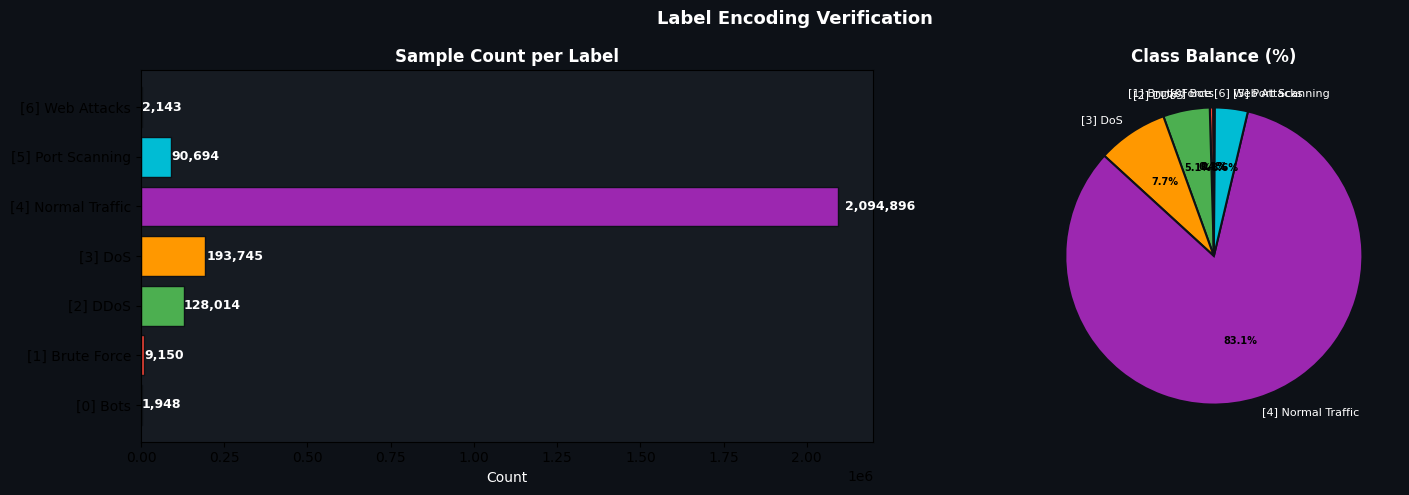

Label encoding looks correct - ready for model training!


In [5]:
# Visual: label distribution
COLORS = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0','#00BCD4','#FFC107','#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('Label Encoding Verification', fontsize=13, fontweight='bold', color='white')

counts = df.groupby(['label','Attack Type']).size().reset_index(name='count').sort_values('label')
labels_str = [f"[{int(r['label'])}] {r['Attack Type']}" for _, r in counts.iterrows()]

# Bar
ax = axes[0]
ax.set_facecolor('#161B22')
bars = ax.barh(labels_str, counts['count'], color=COLORS[:len(counts)], edgecolor='#0D1117')
for bar, val in zip(bars, counts['count']):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9, fontweight='bold', color='white')
ax.set_title('Sample Count per Label', fontweight='bold', color='white')
ax.set_xlabel('Count', color='white')

# Pie
ax2 = axes[1]
ax2.set_facecolor('#0D1117')
wedges, texts, autotexts = ax2.pie(
    counts['count'], labels=labels_str,
    colors=COLORS[:len(counts)], autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor':'#0D1117','linewidth':1.5}
)
for t in texts: t.set_fontsize(8); t.set_color('white')
for a in autotexts: a.set_fontsize(7); a.set_fontweight('bold')
ax2.set_title('Class Balance (%)', fontweight='bold', color='white')

plt.tight_layout()
plt.show()
print('Label encoding looks correct - ready for model training!')

In [6]:
# Columns identify
DROP_COLS = ['Attack Type', 'label'] 

feature_cols = [c for c in df.columns if c not in DROP_COLS]
print(f'Feature columns : {len(feature_cols)}')
print(f'Target column   : label')
print(f'Classes         : {sorted(df["label"].unique())}')
print()
print('Feature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2}. {col}')

Feature columns : 32
Target column   : label
Classes         : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Feature list:
   1. Flow Duration
   2. Flow IAT Max
   3. Packet Length Variance
   4. Subflow Fwd Bytes
   5. Init_Win_bytes_backward
   6. Destination Port
   7. Max Packet Length
   8. Packet Length Std
   9. Fwd Packet Length Mean
  10. Bwd Packet Length Mean
  11. Fwd IAT Total
  12. Idle Mean
  13. Fwd IAT Mean
  14. Bwd Packet Length Max
  15. Flow_Duration_Log
  16. Flow Bytes/s
  17. Bwd Packet Length Std
  18. PSH Flag Count
  19. Fwd_Bwd_Len_Ratio
  20. Fwd Packet Length Max
  21. Pkt_Len_CV
  22. Idle Max
  23. Fwd IAT Max
  24. Bwd Header Length
  25. Total Length of Fwd Packets
  26. Fwd IAT Std
  27. IAT_Regularity
  28. Packet Length Mean
  29. Fwd Header Length
  30. Bytes_Per_Packet
  31. Bwd Packets/s
  32. Average Packet Size


In [7]:
X = df[feature_cols].values
y = df['label'].values

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

### Random Forest Classifier

In [9]:
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                              precision_score, recall_score, f1_score)
import numpy as np

indices_keep = []
for cls in np.unique(y_train):
    cls_idx = np.where(y_train == cls)[0]
    if len(cls_idx) > 50_000:
        cls_idx = np.random.RandomState(42).choice(cls_idx, 50_000, replace=False)
    indices_keep.append(cls_idx)

indices_keep = np.concatenate(indices_keep)
X_tr_small = X_train[indices_keep]
y_tr_small = y_train[indices_keep]

print(f"Reduced: {dict(zip(*np.unique(y_tr_small, return_counts=True)))}")

print("Start SmoteTomek Training:")
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X_tr_small, y_tr_small)

print(f"After SMOTE: {dict(zip(*np.unique(y_res, return_counts=True)))}")

Reduced: {np.int64(0): np.int64(1559), np.int64(1): np.int64(7320), np.int64(2): np.int64(50000), np.int64(3): np.int64(50000), np.int64(4): np.int64(50000), np.int64(5): np.int64(50000), np.int64(6): np.int64(1714)}
Start SmoteTomek Training:
After SMOTE: {np.int64(0): np.int64(49935), np.int64(1): np.int64(49982), np.int64(2): np.int64(49983), np.int64(3): np.int64(49914), np.int64(4): np.int64(49844), np.int64(5): np.int64(49977), np.int64(6): np.int64(49935)}


In [10]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_res, y_res)

y_pred_rf = rf.predict(X_test)

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_rec  = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1   = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f'Accuracy  : {rf_acc*100:.2f}%')
print(f'Precision : {rf_prec*100:.2f}%')
print(f'Recall    : {rf_rec*100:.2f}%')
print(f'F1-Score  : {rf_f1*100:.2f}%')

Accuracy  : 98.94%
Precision : 99.70%
Recall    : 98.94%
F1-Score  : 99.28%


In [11]:
# Per-class report
label_names = dict(df[['label','Attack Type']].drop_duplicates().values)
target_names = [label_names[i] for i in sorted(label_names.keys())]
print('Per-Class Classification Report (Random Forest):')
print('=' * 65)
print(classification_report(y_test, y_pred_rf,
      target_names=target_names, zero_division=0))

Per-Class Classification Report (Random Forest):
                precision    recall  f1-score   support

          Bots       0.09      0.99      0.16       389
   Brute Force       0.96      1.00      0.98      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       0.98      1.00      0.99     38749
Normal Traffic       1.00      0.99      0.99    418979
 Port Scanning       0.99      1.00      0.99     18139
   Web Attacks       0.59      1.00      0.74       429

      accuracy                           0.99    504118
     macro avg       0.80      1.00      0.84    504118
  weighted avg       1.00      0.99      0.99    504118



In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score


lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


In [13]:
lgbm.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.1
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [14]:
y_pred_lgbm = lgbm.predict(X_test)

label_names  = dict(df[['label','Attack Type']].drop_duplicates().values)
target_names = [label_names[i] for i in sorted(label_names.keys())]

print('Per-Class Classification Report (LightGBM):')
print('=' * 65)
print(classification_report(y_test, y_pred_lgbm,
      target_names=target_names, zero_division=0))

d:\FYP\FYP-Practical-Implementation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Per-Class Classification Report (LightGBM):
                precision    recall  f1-score   support

          Bots       0.52      0.87      0.65       389
   Brute Force       1.00      1.00      1.00      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       0.98      1.00      0.99     38749
Normal Traffic       1.00      1.00      1.00    418979
 Port Scanning       0.99      1.00      0.99     18139
   Web Attacks       0.85      0.99      0.92       429

      accuracy                           1.00    504118
     macro avg       0.91      0.98      0.94    504118
  weighted avg       1.00      1.00      1.00    504118



In [ ]:
import pickle

with open('lgbm_model.pkl', 'wb') as f:
    pickle.dump(lgbm, f)

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,      # imbalance handle
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('Per-Class Classification Report (XGBoost):')
print('=' * 65)


Per-Class Classification Report (XGBoost):


In [13]:
from sklearn.metrics import classification_report, accuracy_score

print('Per-Class Classification Report (XGBoost):')
print('=' * 65)
print(classification_report(y_test, y_pred_xgb, zero_division=0))

Per-Class Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.82      0.50      0.62       389
           1       1.00      1.00      1.00      1830
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00     38749
           4       1.00      1.00      1.00    418979
           5       0.99      1.00      0.99     18139
           6       0.99      0.98      0.98       429

    accuracy                           1.00    504118
   macro avg       0.97      0.92      0.94    504118
weighted avg       1.00      1.00      1.00    504118



In [15]:
!pip install catboost

  Using cached plotly-6.6.0-py3-none-any.whl.metadata (8.5 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.3 MB/s eta 0:01:20
   ---------------------------------------- 0.8/101.7 MB 1.3 MB/s eta 0:01:21
   ---------------------------------------- 1.0/101.7 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 1.3/101.7 MB 1.4 MB/s eta 0:01:14
    --------------------------------------- 1.6/101.7 MB 1.4 MB/s eta 0:01:13
    --------------------------------------- 2.1/101.7 MB 1.5 MB/s eta 0:01:08
    --------------------------------------- 2.4/101.7 MB 1.5 MB/s eta 0:01:06
   - -------------------------------------- 2.6/101.7 MB 1.6 MB/s eta 0:01:04
   - -------------------------------------- 2.9/101.7 MB 1.5 MB/s eta 0:01:05
   - -----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    auto_class_weights='Balanced',  # imbalance handle
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)
y_pred_cat = cat.predict(X_test)

print('Per-Class Classification Report (CatBoost):')
print('=' * 65)
print(classification_report(y_test, y_pred_cat, zero_division=0))

Per-Class Classification Report (CatBoost):
              precision    recall  f1-score   support

           0       0.31      0.99      0.47       389
           1       0.98      1.00      0.99      1830
           2       1.00      1.00      1.00     25603
           3       0.98      1.00      0.99     38749
           4       1.00      1.00      1.00    418979
           5       0.99      1.00      0.99     18139
           6       0.67      1.00      0.80       429

    accuracy                           1.00    504118
   macro avg       0.85      1.00      0.89    504118
weighted avg       1.00      1.00      1.00    504118

